# Customer Churn Prediction: Feature Engineering

This notebook constructs the customer-level modeling dataset used to train
a churn prediction model.

The EDA identified several key drivers of churn:

- **Engagement intensity (Frequency)** is the strongest churn signal.
- **Customer value (Monetary)** strongly differentiates churned and active users.
- **Recency** provides a natural churn definition using inactivity thresholds.
- **Early lifecycle behavior** indicates that many customers purchase only once.
- **Seasonality (Q4)** slightly affects purchasing behavior.

Using these insights, we construct features that capture **customer engagement,
value, lifecycle stage, and seasonal behavior**.

To avoid data leakage and simulate real-world predictions, features are generated
using a **time-based sliding window framework**.

## 1. Setup & Data Preparation

During EDA, the analysis was restricted to **United Kingdom customers**
to ensure consistent purchasing behavior and avoid confounding effects
from international shipping differences.

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from tqdm import tqdm
from src.churn.config import *
from src.churn.feature_pipeline import extract_features_for_window

In [3]:
retail_df = pd.read_parquet('../data/processed/online_retail_cleaned.parquet')
uk_df = retail_df[retail_df['Country'] == 'United Kingdom'].copy()

print("Dataset Summary")
print("-" * 55)
print(f"Shape: {uk_df.shape[0]:,} rows × {uk_df.shape[1]} columns")
print(f"Date range: {uk_df['InvoiceDate'].min()} → {uk_df['InvoiceDate'].max()}")
print(f"Unique customers: {uk_df['CustomerID'].nunique():,}")
print(f"Total transactions: {len(uk_df):,}")

# Quick validation of required columns
required_cols = ['CustomerID', 'InvoiceDate', 'Invoice', 'TotalSum', 'TransactionType']
missing_cols = [col for col in required_cols if col not in uk_df.columns]

if missing_cols:
    raise ValueError(f"Missing required columns: {missing_cols}")

print("All required columns present")

Dataset Summary
-------------------------------------------------------
Shape: 716,069 rows × 11 columns
Date range: 2009-12-01 07:45:00 → 2011-12-09 12:49:00
Unique customers: 5,407
Total transactions: 716,069
All required columns present


## 2. Sliding Window Configuration

The churn prediction dataset is constructed using a sliding window approach. For each prediction point, features are computed from historical transaction data within the **observation window**, while churn is determined based on customer activity during the subsequent **prediction window**.

**Window configuration**
- **Observation window**: 180 days
- **Prediction window**: 90 days
- **Sliding step**: 30 days

Only customers with **at least 30 days** of historical data are included in the analysis, ensuring that each customer has sufficient activity history for feature generation.

In [4]:
print("Feature Engineering Configuration")
print("-" * 35)
print(f"Observation window: {OBSERVATION_WINDOW_DAYS} days")
print(f"Prediction window: {PREDICTION_WINDOW_DAYS} days")
print(f"Window step: {WINDOW_STEP_DAYS} days")
print(f"Min customer history: {MIN_CUSTOMER_HISTORY_DAYS} days")

Feature Engineering Configuration
-----------------------------------
Observation window: 180 days
Prediction window: 90 days
Window step: 30 days
Min customer history: 30 days


The observation window length was chosen to capture meaningful purchasing
behavior while avoiding overly sparse data for infrequent customers.

## 3. Window Generation

In [5]:
def generate_window_starts(df, obs_window_days, pred_window_days, step_days):
    """
    Generate start dates for sliding windows based on data availability.
    
    Parameters:
    -----------
    df : DataFrame
        Transaction data with InvoiceDate column
    obs_window_days : int
        Length of observation window
    pred_window_days : int
        Length of prediction window
    step_days : int
        Step size between windows
    
    Returns:
    --------
    DatetimeIndex of window start dates
    """
    min_date = df['InvoiceDate'].min()
    max_date = df['InvoiceDate'].max()
    
    first_possible_start = min_date + timedelta(days=obs_window_days)
    last_possible_start = max_date - timedelta(days=pred_window_days)
    
    if first_possible_start > last_possible_start:
        raise ValueError(f"Insufficient data: Need at least {obs_window_days + pred_window_days} days")
    
    window_starts = pd.date_range(
        start=first_possible_start,
        end=last_possible_start,
        freq=f'{step_days}D'
    )
    
    return window_starts

In [6]:
window_starts = generate_window_starts(
    uk_df, 
    OBSERVATION_WINDOW_DAYS, 
    PREDICTION_WINDOW_DAYS, 
    WINDOW_STEP_DAYS
)
print(f"Generated {len(window_starts)} windows from {window_starts[0].date()} to {window_starts[-1].date()}")

Generated 16 windows from 2010-05-30 to 2011-08-23


### Feature Design Strategy

Features are designed to capture key behavioral dimensions identified during EDA and validated through model-based feature selection:

- **Customer value & engagement** → RFM features (Recency, Frequency, Monetary)
- **Early lifecycle behavior** → first-month activity and spend
- **Purchase behavior & diversity** → product variety and return patterns
- **Timing & regularity** → purchase intervals and delay metrics
- **Engagement intensity** → density of activity over time

Feature selection was refined through an ablation study, where groups of features were systematically removed and model performance was evaluated.

Key findings:
- RFM features provide the strongest predictive signal
- Early lifecycle and product features significantly improve churn detection
- Timing and engagement features add complementary signal
- Trend-based features were redundant and removed, as they did not improve model performance

Where appropriate, features are normalized or expressed as ratios to improve comparability across customers with different activity levels.

## 4. Feature Definitions

The table below describes all features generated for the churn prediction model. Features are grouped by category, with their interpretation and relationship to churn based on EDA findings.

| Feature | Category | Definition | Interpretation |
|:--------|:---------|:-----------|:---------------|
| Recency | RFM | Days since last purchase | Customer inactivity |
| Frequency | RFM | Number of purchases | Engagement intensity |
| Monetary | RFM | Total spend | Customer value |
| LogFrequency | RFM (transformed) | log(Frequency + 1) | Normalized engagement |
| LogMonetary | RFM (transformed) | log(Monetary + 1) | Normalized value |
| AvgOrderValue | AOV | Mean transaction value | Typical order size |
| OrderValueCV | AOV | Variability of order value (std/mean) | Spending consistency |
| IsOrderValueCVDefined | AOV | Indicator for valid CV computation | Data reliability |
| ReturnRate | Product behavior | Proportion of purchases returned | Product satisfaction |
| UniqueProducts | Product behavior | Number of distinct products purchased | Purchase diversity |
| Q4Ratio | Seasonality | Proportion of purchases in Q4 (Oct–Dec) | Holiday-driven behavior |
| FavoriteMonth | Seasonality | Most frequent purchase month | Preferred shopping period |
| FirstMonthPurchases | Early lifecycle | Purchases in first 30 days | Initial engagement |
| MonetaryFirstMonth | Early lifecycle | Spend in first 30 days | Initial customer value |
| AvgOrderValueFirstMonth | Early lifecycle | Avg order value in first month | Quality of early engagement |
| IsNewCustomerTrend | Behavioral flag | Customer has only recent activity | New/emerging customer |
| NoHistoricalActivity | Behavioral flag | No activity before recent period | Lack of history |
| CustomerLifetime | Lifecycle | Days since first purchase | Customer maturity |
| AvgPurchaseInterval | Timing | Mean days between purchases | Purchase cadence |
| PurchaseIntervalCV | Timing | Variability of intervals | Regularity of behavior |
| IsPurchaseIntervalCVDefined | Timing | Indicator for valid interval CV | Data reliability |
| DelayRatio | Engagement | Recency / avg purchase interval | Deviation from normal behavior |
| EngagementDensity | Engagement | Active days / observation window | Activity consistency |
| IsChurned | Target | 1 if no purchases in prediction window | Churn label |

Trend-based features (e.g., revenue and frequency trends) were initially included but removed after empirical evaluation showed no improvement in model performance. Their predictive signal was largely captured by RFM and recent activity features.

## 5. Feature Extraction
The core feature engineering logic is handled by the `extract_features_for_window` function from our `feature_pipeline` module. For transparency, here is its docstring, which outlines the detailed steps it performs for a single time window:

In [7]:
print(extract_features_for_window.__doc__)


Extract all features for a single window.

Parameters:
-----------
df : DataFrame
    Full transaction dataset
window_start : datetime
    Start date of the observation window
window_size_days : int
    Length of observation window in days
churn_threshold_days : int
    Number of days without purchase to consider as churned
min_customer_history : int, default=30
    Minimum number of days between first and last transaction required
    for a customer to be considered valid

Returns:
--------
features : DataFrame
    Complete feature set with labels for the window



In [8]:
all_windows = []
window_stats = []

for i, window_start in enumerate(tqdm(window_starts, desc="Processing")):
   # try:
        window_features = extract_features_for_window(
            uk_df, window_start, OBSERVATION_WINDOW_DAYS, 
            PREDICTION_WINDOW_DAYS, MIN_CUSTOMER_HISTORY_DAYS
        )
        
        if window_features is not None and len(window_features) > 50:
            all_windows.append(window_features)
            window_stats.append({
                'window': i+1,
                'customers': len(window_features),
                'churn_rate': window_features['IsChurned'].mean()
            })
            
    #except Exception as e:
     #   print(f"✗ Window {i+1}: {traceback.format_exc()}")
      #  break

Processing:   6%|██                              | 1/16 [00:00<00:11,  1.27it/s]

Validation issues for 200912_201005:
    - Extreme outliers in IsNewCustomerTrend (values > 0.00)
    - Extreme outliers in NoHistoricalActivity (values > 0.00)


Processing:  12%|████                            | 2/16 [00:01<00:10,  1.33it/s]

Validation issues for 200912_201006:
    - Extreme outliers in IsNewCustomerTrend (values > 0.00)
    - Extreme outliers in NoHistoricalActivity (values > 0.00)


Processing:  19%|██████                          | 3/16 [00:02<00:09,  1.32it/s]

...

Validation issues for 201012_201106:
    - Extreme outliers in IsNewCustomerTrend (values > 0.00)


Processing:  94%|█████████████████████████████  | 15/16 [00:11<00:00,  1.37it/s]

Validation issues for 201101_201107:
    - Extreme outliers in IsNewCustomerTrend (values > 0.00)
    - Extreme outliers in NoHistoricalActivity (values > 0.00)


Processing: 100%|███████████████████████████████| 16/16 [00:12<00:00,  1.27it/s]

Validation issues for 201102_201108:
    - Extreme outliers in IsNewCustomerTrend (values > 0.00)
    - Extreme outliers in NoHistoricalActivity (values > 0.00)


### Note on Validation Warnings

The validation warnings during feature extraction indicate the presence of extreme values in several features, including:

- OrderValueCV: Customers with highly variable spending patterns
- MonetaryRecent: High-value customers with large recent transactions
- FirstMonthSpend: Customers with large initial purchases

These outliers represent legitimate customer segments (e.g., business buyers or bulk purchasers) rather than data errors.

Tree-based models used in the modeling phase are robust to such values, so these observations are retained.

## Feature Selection Summary

Feature selection was refined through an iterative process combining domain knowledge, exploratory data analysis, and model-based evaluation.

An ablation study was conducted to assess the contribution of each feature group. The results showed:

- RFM features are the primary drivers of model performance
- Early lifecycle features significantly improve identification of one-time and early-churn customers
- Product and timing features provide complementary behavioral signals
- Trend-based features were redundant and removed without loss of performance

The final feature set balances predictive performance, interpretability, and robustness, and avoids unnecessary feature redundancy.

## 6. Final Dataset Assembly & Quality Checks

In [9]:
if len(all_windows) == 0:
    raise ValueError("No windows were generated. Check window configuration or input data.")

### 6.1 Dataset Assembly

In this step, all window-level feature datasets are combined into a single modeling table.
Each row represents a customer observation within a specific temporal window, identified by the pair (CustomerID, WindowID).
After assembling the dataset, basic dataset statistics and structural validation checks are performed.

In [10]:
final_dataset = pd.concat(all_windows, ignore_index=True)

if final_dataset.empty:
    raise RuntimeError("Final dataset is empty. Nothing to analyze.")

In [11]:
print(f"Dataset shape: {final_dataset.shape}")
print(f"Unique customers: {final_dataset['CustomerID'].nunique()}")
print(f"Number of windows: {final_dataset['WindowID'].nunique()}")

Dataset shape: (21110, 28)
Unique customers: 2775
Number of windows: 16


To ensure the feature engineering pipeline produced valid observations, we verify that each (CustomerID, WindowID) pair appears only once in the dataset.
This guarantees that each customer has a single feature vector per temporal window.

In [12]:
dup_count = final_dataset.duplicated(subset=["CustomerID", "WindowID"]).sum()
print("Duplicate customer-window rows:", dup_count)

assert dup_count == 0, "Duplicate (CustomerID, WindowID) rows detected"

Duplicate customer-window rows: 0


### 6.2 Dataset Diagnostics
This section performs diagnostic checks on the assembled dataset.
We examine feature structure, class balance, and data quality, and verify that sliding window statistics remain consistent across time.

### 6.2.1 Feature and Target Overview
This subsection summarizes the structure of the final modeling dataset. Feature definitions were introduced in Section 4; here we focus on the number of engineered features and the distribution of the target variable

In [13]:
meta_cols = ["CustomerID", "WindowStart", "WindowEnd", "WindowID", "IsChurned"]
feature_cols = [c for c in final_dataset.columns if c not in meta_cols]
churn_rate = final_dataset["IsChurned"].mean()
churned = final_dataset["IsChurned"].sum()
active = len(final_dataset) - churned

In [14]:
print("Target Distribution")
print("-"*25)
print(f"Churned: {churned:,} ({churn_rate:.1%})")
print(f"Active:  {active:,} ({1 - churn_rate:.1%})")

Target Distribution
-------------------------
Churned: 6,716 (31.8%)
Active:  14,394 (68.2%)


In [15]:
print(f"Number of features: {len(feature_cols)}")

Number of features: 23


### 6.2.2 Data Quality Checks
Before proceeding, we perform basic data quality checks on the engineered features. Specifically, we verify that the dataset contains no missing values or infinite values, which could arise from division operations or log transformations during feature engineering.

In [16]:
feature_data = final_dataset[feature_cols]

missing = feature_data.isna().values.sum()
inf_count = np.isinf(feature_data).sum().sum()
total_cells = feature_data.size

print("Data Quality")
print("-"*30)
print(f"Missing values: {missing} ({missing / total_cells:.2%})")
print(f"Infinite values: {inf_count}")
print("Data looks good!" if missing == 0 and inf_count == 0 else "Issues detected")

Data Quality
------------------------------
Missing values: 0 (0.00%)
Infinite values: 0
Data looks good!


### 6.2.3 Window-Level Statistics

In [17]:
stats_df = pd.DataFrame(window_stats)

assert len(stats_df) > 0, "window_stats is empty"

print("Per-Window Stats")
print("-"*30)
print(f"Customers: {stats_df['customers'].min()} – {stats_df['customers'].max()}")
print(f"Churn rate: {stats_df['churn_rate'].min():.1%} – {stats_df['churn_rate'].max():.1%}")

Per-Window Stats
------------------------------
Customers: 1129 – 1554
Churn rate: 21.4% – 46.2%


Since the dataset was constructed using sliding temporal windows, we examine the number of customers and churn rate within each window. This helps verify that the window generation process produced consistent observations and that the target variable varies across time.

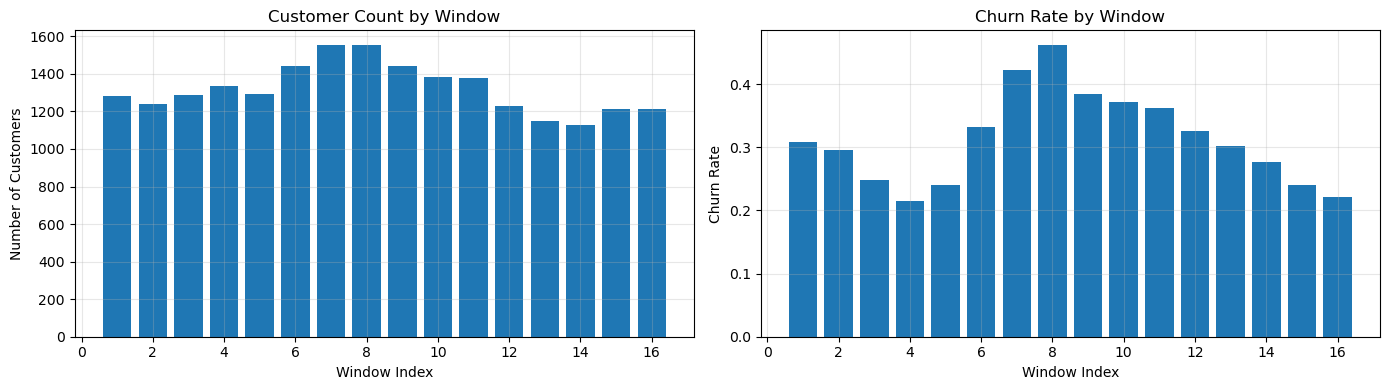

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Window sizes
axes[0].bar(stats_df["window"], stats_df['customers'])
axes[0].set_xlabel('Window Index')
axes[0].set_ylabel('Number of Customers')
axes[0].set_title('Customer Count by Window')
axes[0].grid(True, alpha=0.3)

# Churn rates
axes[1].bar(stats_df["window"], stats_df['churn_rate'])
axes[1].set_xlabel('Window Index')
axes[1].set_ylabel('Churn Rate')
axes[1].set_title('Churn Rate by Window')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6.3 Feature Stability Analysis
It is important to verify that engineered features remain stable over time. Large shifts in feature values or distributions could indicate temporal drift or inconsistencies in the feature engineering pipeline.

We therefore examine both the mean feature values across windows and the feature distributions for selected windows.

Log-transformed variants of some features (e.g., LogFrequency, LogMonetary) are used later during modeling to mitigate skewness. For interpretability, the stability analysis focuses on the original behavioral features.

In [19]:
# Key features to monitor for stability
key_features = [
    "Recency",
    "Frequency",
    "Monetary",
 #   "RevenueTrend",
    "DelayRatio"
]

missing_features = [f for f in key_features if f not in final_dataset.columns]
assert not missing_features, f"Missing expected features: {missing_features}"

window_means = final_dataset.groupby("WindowID")[key_features].mean()

### 6.3.1 Feature Mean Stability

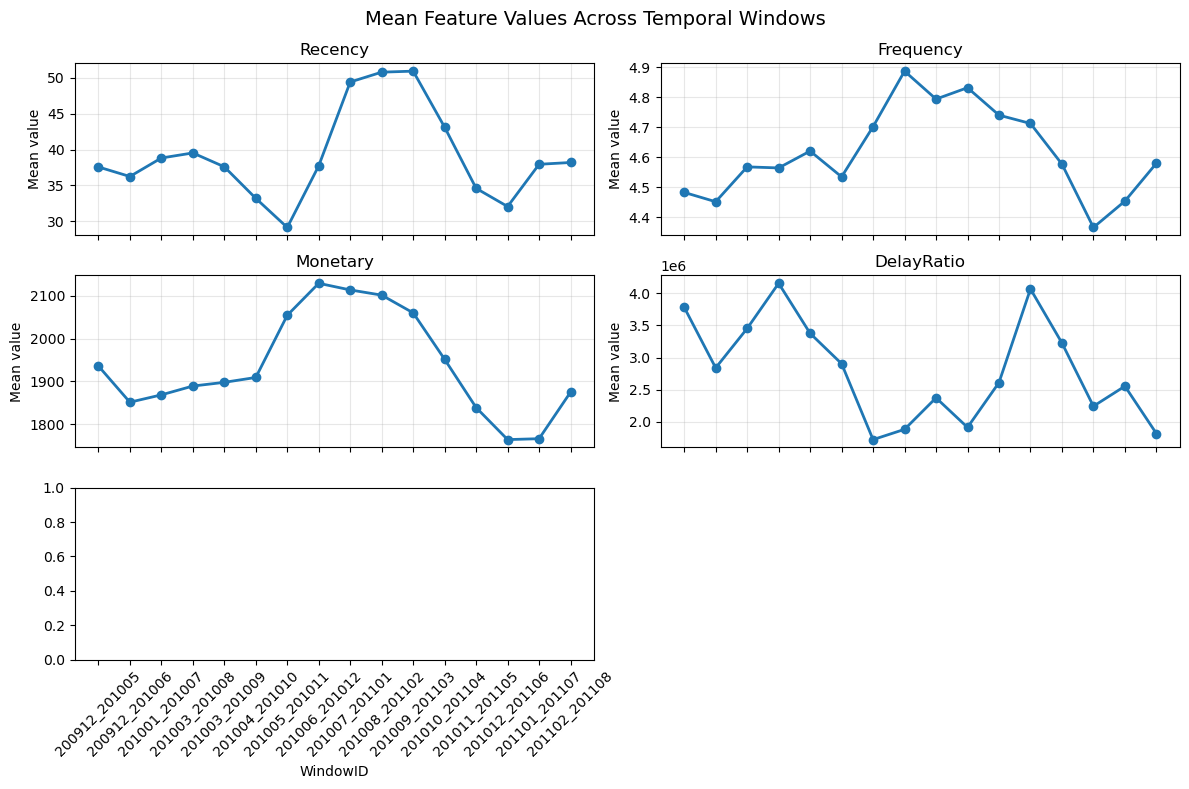

In [20]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8), sharex=True)
axes = axes.flatten()

for i, feature in enumerate(key_features):
    axes[i].plot(
        window_means.index,
        window_means[feature],
        marker="o",
        linewidth=2
    )
    
    axes[i].set_title(feature)
    axes[i].set_ylabel("Mean value")
    axes[i].grid(True, alpha=0.3)

fig.delaxes(axes[-1])

axes[-2].set_xlabel("WindowID")

plt.suptitle("Mean Feature Values Across Temporal Windows", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The mean values of the monitored features exhibit relatively smooth trends across temporal windows. Frequency remains highly stable, indicating consistent purchasing activity across the dataset. Monetary values show moderate variation but no abrupt spikes, suggesting stable customer spending patterns over time.

Some variation is observed in Recency and InactivityRatio, which is expected given their sensitivity to changes in recent customer activity. However, these changes remain gradual and do not indicate structural instability.

Overall, the absence of sharp shifts in feature means suggests that the engineered features are temporally consistent, reducing the likelihood of significant feature drift prior to model training.

### 6.3.2 Feature Distribution Stability

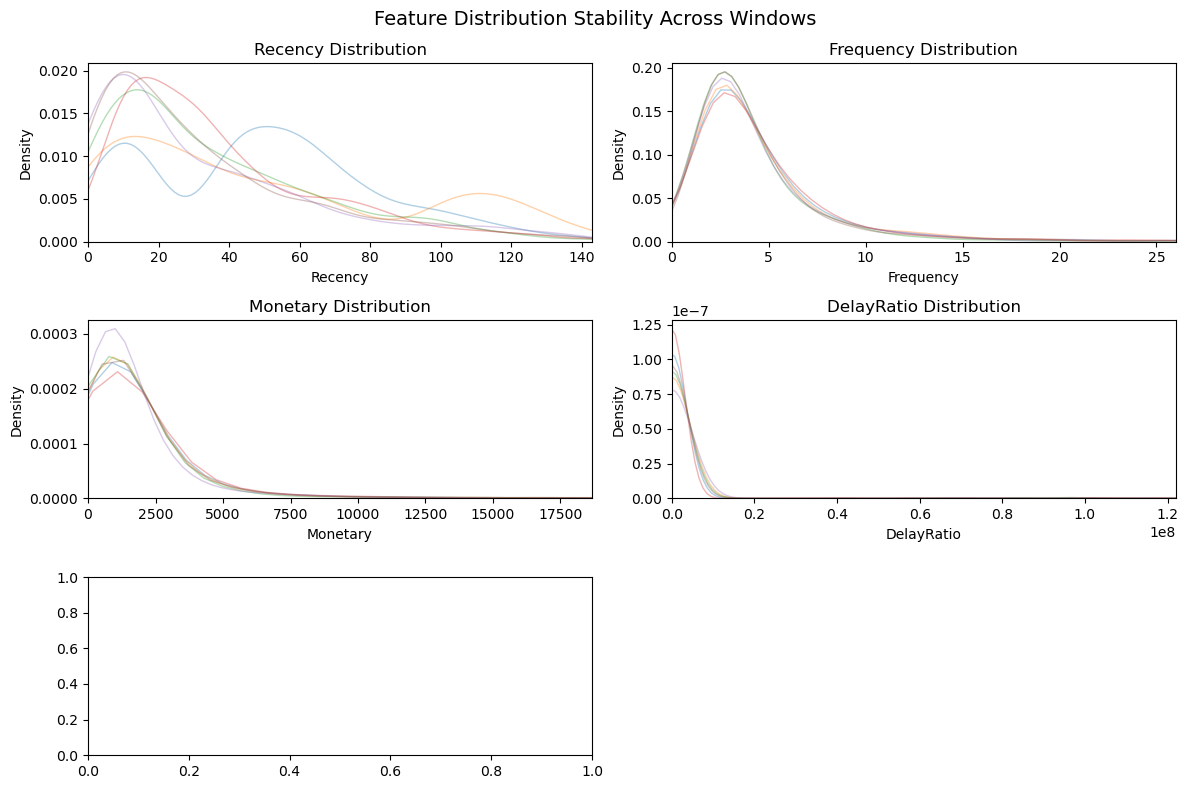

In [21]:
sample_windows = final_dataset["WindowID"].sample(min(6, final_dataset["WindowID"].nunique()), random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    for w in sample_windows:
        sns.kdeplot(
            final_dataset.loc[final_dataset["WindowID"] == w, feature],
            ax=axes[i],
            alpha=0.35,
            linewidth=1
        )
        
    # Limit x-axis to the 99th percentile to reduce extreme outlier effect
    xmax = final_dataset[feature].quantile(0.99)
    axes[i].set_xlim(0, xmax)
        
    axes[i].set_title(f"{feature} Distribution")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

# Remove empty subplot
fig.delaxes(axes[-1])

plt.suptitle("Feature Distribution Stability Across Windows", fontsize=14)
plt.tight_layout()
plt.show()

The distribution plots indicate that the overall shapes of the engineered feature distributions remain largely consistent across sampled temporal windows. Most features exhibit substantial overlap between windows, suggesting stable behavioral patterns over time.

Transaction-related features such as Frequency and Monetary display highly consistent distributions, indicating that customer purchasing activity and spending behavior remain relatively stable across the dataset.

The InactivityRatio feature also shows strong stability, with most observations concentrated at low values and only minor variation in the extreme right tail. This indicates that the relative inactivity of customers compared to their historical purchase cadence remains broadly consistent across windows.

Some moderate variation is visible in the tail behavior of Recency and RevenueTrend, which is expected given their sensitivity to changes in recent customer activity. However, the core distribution shapes remain similar, and no abrupt shifts are observed.

Overall, these results suggest that the engineered behavioral features remain temporally stable, reducing the likelihood of significant feature drift prior to model training.

## 7. Feature-Target Relationships
To gain a preliminary understanding of which behavioral features are associated with customer churn, we compute the correlation between each feature and the target variable (IsChurned).

While correlation alone does not imply causation, it provides a quick indication of which features may carry predictive signal for the churn model.

In [22]:
correlations = final_dataset[feature_cols + ["IsChurned"]] \
    .corr()["IsChurned"] \
    .drop("IsChurned") \
    .sort_values() 

In [23]:
top_corr_abs = correlations.reindex(correlations.abs().sort_values(ascending=False).head(10).index)

print("Top 10 strongest correlates with churn (by absolute correlation):")
print(top_corr_abs.to_string())

Top 10 strongest correlates with churn (by absolute correlation):
LogFrequency                  -0.306419
LogMonetary                   -0.281768
EngagementDensity             -0.242551
Frequency                     -0.213553
Recency                        0.211500
UniqueProducts                -0.175784
Q4Ratio                        0.129538
FirstMonthPurchases           -0.129537
Monetary                      -0.129385
IsPurchaseIntervalCVDefined   -0.107386


Positive correlations indicate features associated with a higher likelihood of churn, while negative correlations indicate features associated with customer retention.

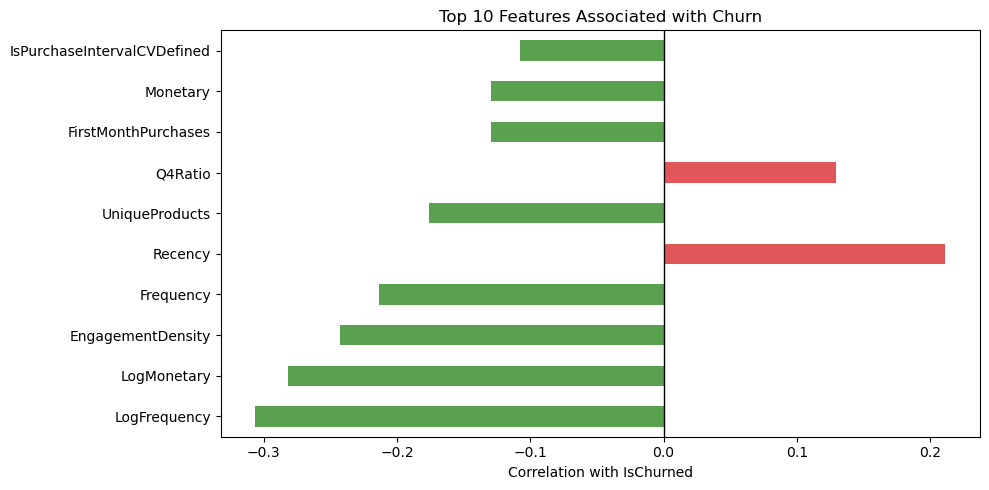

In [24]:
colors = ["#E15759" if v > 0 else "#59A14F" for v in top_corr_abs]

plt.figure(figsize=(10,5))
top_corr_abs.plot(kind="barh", color=colors, title="Top 10 Features Associated with Churn")

plt.axvline(0, color="black", linewidth=1)
plt.xlabel("Correlation with IsChurned")
plt.tight_layout()
plt.show()

To understand which behavioral features are associated with churn, we examine their correlation with the target variable (IsChurned).

**Features with strongest negative correlation (lower churn):**
- LogFrequency (-0.31): More frequent purchases
- LogMonetary (-0.28): Higher spending
- UniqueInvoices (-0.23): More purchase occasions
- Frequency (-0.22): Higher purchase count

**Features with strongest positive correlation (higher churn):**
- Recency (0.19): Longer time since last purchase
- PurchaseDelay (0.18): Purchasing later than typical pattern
- StdPurchaseInterval (0.18): Irregular purchase timing

These patterns align with intuition: engaged customers with consistent, frequent purchasing behavior tend to remain active, while those showing signs of disengagement are at higher risk of churning.

## 8. Save Final Modeling Dataset

In [25]:
final_dataset['WindowStart'].unique()

<DatetimeArray>
['2009-12-01 07:45:00', '2009-12-31 07:45:00', '2010-01-30 07:45:00',
 '2010-03-01 07:45:00', '2010-03-31 07:45:00', '2010-04-30 07:45:00',
 '2010-05-30 07:45:00', '2010-06-29 07:45:00', '2010-07-29 07:45:00',
 '2010-08-28 07:45:00', '2010-09-27 07:45:00', '2010-10-27 07:45:00',
 '2010-11-26 07:45:00', '2010-12-26 07:45:00', '2011-01-25 07:45:00',
 '2011-02-24 07:45:00']
Length: 16, dtype: datetime64[ns]

In [26]:
output_path = "../data/processed/churn_features_sliding_window.parquet"
final_dataset.to_parquet(output_path, index=False)

print(f"Dataset saved to: {output_path}")

Dataset saved to: ../data/processed/churn_features_sliding_window.parquet


## 9. Conclusion

In this notebook we constructed a customer-level modeling dataset for churn prediction using a sliding temporal window approach. Starting from transactional purchase data, a set of behavioral features was engineered to capture purchasing activity, spending behavior, seasonality, and customer engagement patterns.

Several validation steps were performed to ensure the quality and reliability of the engineered features. Dataset assembly checks confirmed the integrity of customer–window observations, while data quality diagnostics verified the absence of missing or infinite values. Temporal stability analysis further demonstrated that the feature distributions remain consistent across windows, reducing the likelihood of significant feature drift.

A preliminary correlation analysis highlighted several behavioral signals associated with churn, particularly features related to customer inactivity and purchasing frequency.

The resulting dataset will be used in the next stage of the project to train and evaluate churn prediction models.